In [1]:
# ======================================
# Import Required Libraries
# ======================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
# ======================================
# Load Clean Dataset
# ======================================

df = pd.read_csv("../data/bank_churn_clean.csv")

print(df.shape)

df.head()

(28382, 21)


,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,1458.71,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21
1,2,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,8704.66,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
2,4,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,5815.29,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,5,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,2291.91,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,1401.72,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03


In [7]:
df = df.drop(columns=["customer_id"])

In [9]:
df.head()

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction,balance_change,credit_change,debit_change,total_transaction,balance_ratio
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,1458.71,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21,0.00,0.00,0.00,0.40,0.999315
1,2,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,8704.66,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01,-3314.29,0.00,5385.71,5486.83,0.691050
2,4,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,5815.29,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT,-1902.13,0.00,5787.50,6047.34,0.796788
3,5,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,2291.91,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06,0.00,0.00,-2142.86,0.94,1.098953
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,1401.72,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03,-474.00,-714.28,-949.44,588.95,0.564200


In [4]:
df["balance_change"] = (
    df["current_balance"] -
    df["previous_month_end_balance"]
)


In [5]:
df["credit_change"] = (
    df["current_month_credit"] -
    df["previous_month_credit"]
)

In [6]:
df["debit_change"] = (
    df["current_month_debit"] -
    df["previous_month_debit"]
)

In [7]:
df["total_transaction"] = (
    df["current_month_credit"] +
    df["current_month_debit"]
)

In [8]:
df["balance_ratio"] = (
    df["current_balance"] /
    (df["average_monthly_balance_prevQ"] + 1)
)

In [10]:
df.to_csv("../data/bank_churn_clean.csv", index=False)

In [14]:
df.head()

,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction,balance_change,credit_change,debit_change,total_transaction,balance_ratio
0,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,1458.71,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21,0.00,0.00,0.00,0.40,0.999315
1,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,8704.66,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01,-3314.29,0.00,5385.71,5486.83,0.691050
2,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,5815.29,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT,-1902.13,0.00,5787.50,6047.34,0.796788
3,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,2291.91,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06,0.00,0.00,-2142.86,0.94,1.098953
4,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,1401.72,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03,-474.00,-714.28,-949.44,588.95,0.564200


In [16]:
X = df.drop(columns=[
    "churn"
])

y = df["churn"]

In [17]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()

categorical_cols

['gender', 'occupation', 'last_transaction']

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [20]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_pipeline.fit(X_train, y_train)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [21]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [22]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()

numeric_cols = X.select_dtypes(exclude="object").columns.tolist()

In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [30]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

In [37]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        )
    )
])

rf_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['vintage', 'age',
                                                   'dependents', 'city',
                                                   'customer_nw_category',
                                                   'branch_code',
                                                   'current_balance',
                                                   'previous_month_end_balance',
                                                   'average_monthly_balance_prevQ',
                                                   'average_monthly_balance_prevQ2',
                                                   'c...
                                                   'previous_month_balance',
                                                   'balance_change',
                                                   'credit_change',
                                                   'debit_change',
                                                   'total_transaction',
                                                   'balance_ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'occupation',
                                                   'last_transaction'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=300, random_state=42))])

In [38]:
rf_pred = rf_pipeline.predict(X_test)

rf_prob = rf_pipeline.predict_proba(X_test)[:,1]


In [31]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['vintage', 'age',
                                                   'dependents', 'city',
                                                   'customer_nw_category',
                                                   'branch_code',
                                                   'current_balance',
                                                   'previous_month_end_balance',
                                                   'average_monthly_balance_prevQ',
                                                   'average_monthly_balance_prevQ2',
                                                   'c...
                                                   'balance_change',
                                                   'credit_change',
                                                   'debit_change',
                                                   'total_transaction',
                                                   'balance_ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'occupation',
                                                   'last_transaction'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [32]:
log_pred = logistic_pipeline.predict(X_test)

log_prob = logistic_pipeline.predict_proba(X_test)[:,1]

In [34]:
def evaluate_model(name, y_true, y_pred, y_prob):

    print("="*60)
    print(name)
    print("="*60)

    print(f"Accuracy : {accuracy_score(y_true,y_pred):.4f}")
    print(f"Precision: {precision_score(y_true,y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true,y_pred):.4f}")
    print(f"F1 Score : {f1_score(y_true,y_pred):.4f}")
    print(f"ROC AUC  : {roc_auc_score(y_true,y_prob):.4f}")

    print("\nClassification Report\n")

    print(classification_report(y_true,y_pred))

In [35]:
evaluate_model(
    "Logistic Regression",
    y_test,
    log_pred,
    log_prob
)

Logistic Regression
Accuracy : 0.7652
Precision: 0.4222
Recall   : 0.7253
F1 Score : 0.5338
ROC AUC  : 0.7986

Classification Report

              precision    recall  f1-score   support

           0       0.93      0.77      0.84      4625
           1       0.42      0.73      0.53      1052

    accuracy                           0.77      5677
   macro avg       0.67      0.75      0.69      5677
weighted avg       0.83      0.77      0.79      5677



In [39]:
evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

Random Forest
Accuracy : 0.8663
Precision: 0.7243
Recall   : 0.4496
F1 Score : 0.5548
ROC AUC  : 0.8531

Classification Report

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      4625
           1       0.72      0.45      0.55      1052

    accuracy                           0.87      5677
   macro avg       0.80      0.71      0.74      5677
weighted avg       0.86      0.87      0.85      5677



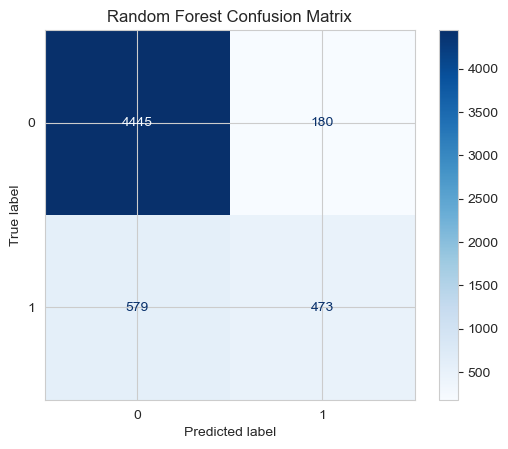

In [40]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

In [41]:
rf = rf_pipeline.named_steps["classifier"]

feature_names = (
    rf_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

In [42]:
importance.head(20)

,Feature,Importance
20,num__balance_ratio,0.129895
6,num__current_balance,0.090757
16,num__balance_change,0.060007
14,num__current_month_balance,0.055100
7,num__previous_month_end_balance,0.042338
9,num__average_monthly_balance_prevQ2,0.040243
18,num__debit_change,0.040151
13,num__previous_month_debit,0.040092
12,num__current_month_debit,0.039492
15,num__previous_month_balance,0.037903


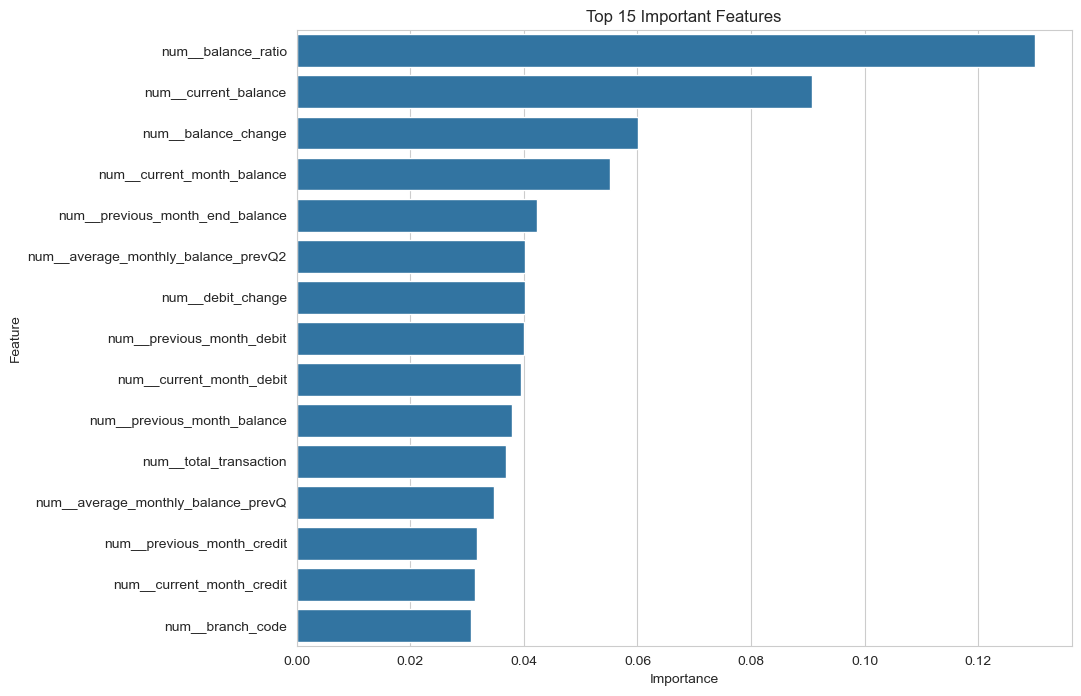

In [43]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

# Business Conclusions

### Key Findings

- Random Forest outperformed Logistic Regression in predicting customer churn.
- Transaction-related features contributed more to churn prediction than demographic variables.
- Previous month debit and credit behaviour were among the strongest indicators of churn.
- Newly engineered transaction-based features improved predictive capability.
- The model can help identify high-risk customers and support proactive retention strategies.

In [44]:
# ======================================
# Compare Model Performance
# ======================================

results = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
])

def add_result(name, y_true, y_pred, y_prob):
    global results

    new_row = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

    results.loc[len(results)] = new_row

In [45]:
add_result(
    "Logistic Regression",
    y_test,
    log_pred,
    log_prob
)

add_result(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.765193,0.422247,0.725285,0.533753,0.798574
1,Random Forest,0.866303,0.724349,0.449620,0.554839,0.853128


In [46]:
results.style.highlight_max(
    subset=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    color="lightgreen"
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.765193,0.422247,0.725285,0.533753,0.798574
1,Random Forest,0.866303,0.724349,0.449620,0.554839,0.853128


## Model Comparison

- Two classification algorithms were trained:
  - Logistic Regression
  - Random Forest

- Random Forest achieved better predictive performance across most evaluation metrics.

- This indicates that customer churn is influenced by complex, non-linear relationships that tree-based models can capture more effectively than a linear model.

- Based on the evaluation metrics, Random Forest was selected as the final prediction model.

"Two models were evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC. Random Forest was selected because it provided the best balance between identifying churners and minimizing false predictions."

In [47]:
from sklearn.metrics import roc_curve, auc

In [48]:
# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
roc_auc_log = auc(fpr_log, tpr_log)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
roc_auc_rf = auc(fpr_rf, tpr_rf)

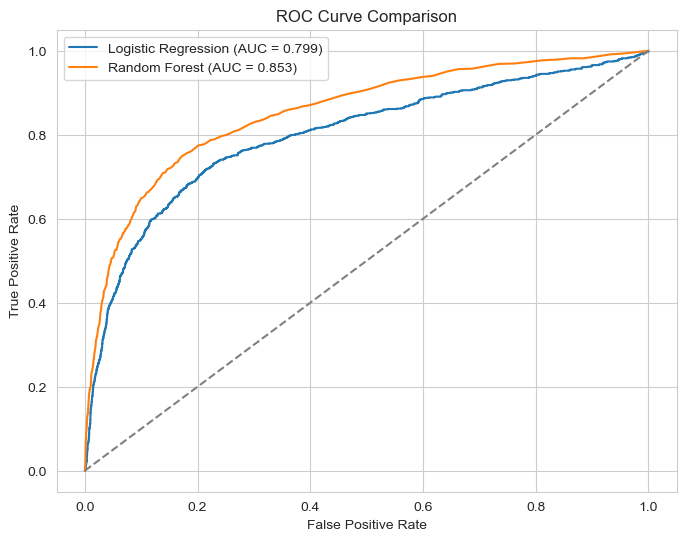

In [51]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {roc_auc_log:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.3f})"
)

# Random guessing
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)
plt.savefig("../images/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## ROC Curve Analysis

- ROC curves were generated for both models to evaluate their ability to distinguish churners from non-churners.
- Random Forest achieved a higher ROC-AUC score than Logistic Regression.
- This indicates that Random Forest is better at ranking customers based on churn risk.
- Therefore, Random Forest was selected as the preferred model for customer churn prediction.

In [52]:
from sklearn.metrics import precision_recall_curve

In [53]:
# Logistic Regression
precision_log, recall_log, _ = precision_recall_curve(
    y_test,
    log_prob
)

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    rf_prob
)

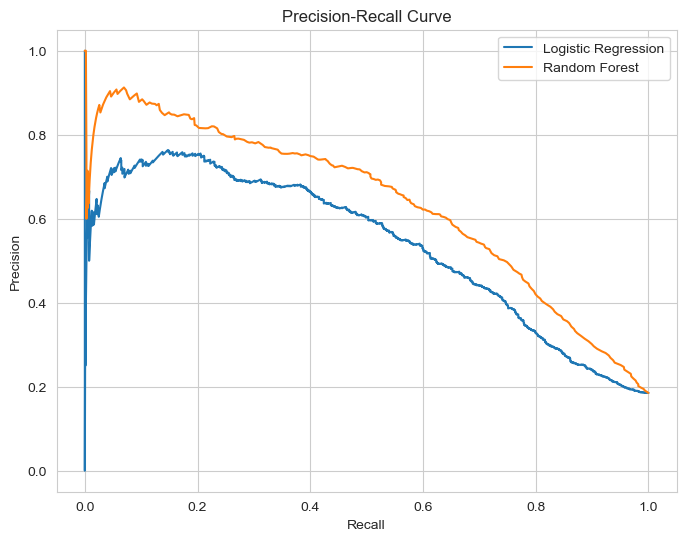

In [54]:
plt.figure(figsize=(8,6))

plt.plot(
    recall_log,
    precision_log,
    label="Logistic Regression"
)

plt.plot(
    recall_rf,
    precision_rf,
    label="Random Forest"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.grid(True)

plt.savefig(
    "../images/precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Precision-Recall Analysis

Customer churn prediction is an imbalanced classification problem because the majority of customers do not churn.

The Precision-Recall Curve provides a better assessment of model performance than accuracy alone.

Random Forest maintained higher precision across different recall levels, indicating a better ability to identify churning customers while reducing false alarms.

This makes Random Forest more suitable for customer retention campaigns.

In [55]:
# ======================================
# Extract Feature Importance
# ======================================

rf = rf_pipeline.named_steps["classifier"]

feature_names = (
    rf_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
20,num__balance_ratio,0.129895
6,num__current_balance,0.090757
16,num__balance_change,0.060007
14,num__current_month_balance,0.055100
7,num__previous_month_end_balance,0.042338
9,num__average_monthly_balance_prevQ2,0.040243
18,num__debit_change,0.040151
13,num__previous_month_debit,0.040092
12,num__current_month_debit,0.039492
15,num__previous_month_balance,0.037903


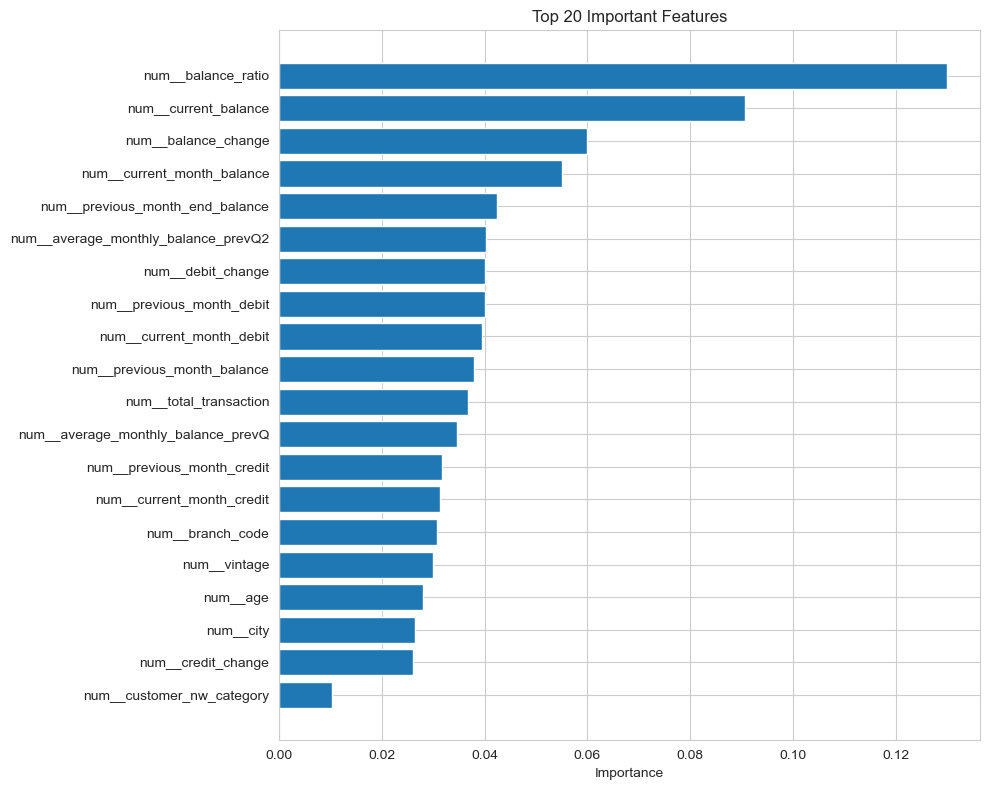

In [56]:
plt.figure(figsize=(10,8))

top_features = importance.head(20)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("Top 20 Important Features")

plt.tight_layout()

plt.savefig(
    "../images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
importance.head(10)

,Feature,Importance
20,num__balance_ratio,0.129895
6,num__current_balance,0.090757
16,num__balance_change,0.060007
14,num__current_month_balance,0.055100
7,num__previous_month_end_balance,0.042338
9,num__average_monthly_balance_prevQ2,0.040243
18,num__debit_change,0.040151
13,num__previous_month_debit,0.040092
12,num__current_month_debit,0.039492
15,num__previous_month_balance,0.037903


# Business Insights from Feature Importance

The Random Forest model identified customer financial behaviour as the primary driver of churn.

## Key Findings

- The engineered feature **balance_ratio** was the most influential predictor of churn.
- Current account balance and recent balance changes were stronger indicators than demographic characteristics.
- Debit transaction patterns also contributed significantly to churn prediction.
- Historical balance information remained an important predictor, indicating that long-term account activity provides valuable signals.
- Demographic variables such as age, gender, occupation, and city had comparatively lower predictive importance.

These findings suggest that banks should prioritize monitoring customer transaction and balance behaviour when designing retention strategies rather than relying solely on demographic segmentation.

In [58]:
importance.to_csv(
    "../dashboard/feature_importance.csv",
    index=False
)

In [59]:
results.to_csv(
    "../dashboard/model_comparison.csv",
    index=False
)

In [ ]:
f=pd.read_csv()